In [ ]:
import os
import torch
import random
import numpy as np
from matplotlib import pyplot as plt
from datetime import datetime
from tqdm import tqdm
import json
from PIL import Image
# from learning.src.models.components.policies.transformer import TransformerPolicy as VITPolicy
from learning.src.models.components.policies.svit import SViTPolicy as VITPolicy
from learning.src.data.components.flight_il_dataset_clean import FlightILDataset
from torchvision import transforms # type: ignore
import pandas as pd
from MCMD_Sim.simulator.simulator_mcmd_exp import MCMDSimEval

In [43]:
def infer(model, init_cond, text_cmd, prefix='', num_step=100, msg = '', logging=False, verbose=False):
    sim = MCMDSimEval(init_cond, 3, log_prefix=prefix, logging=logging)
    image = sim.setup_simulation(verbose=verbose)[0]
    with torch.no_grad():
        for iter in tqdm(range(num_step), desc=msg):
            image = Image.fromarray(image)
            img = image.resize((224, 224))
            img = transforms.ToTensor()(img).to('cuda:0')

            preds = model({"image": img, "text": text_cmd})

            vel_cmd = torch.stack([preds["vx"], preds["vy"], preds["vz"], preds["yaw"]], dim=1).cpu().detach().numpy()
            image = sim.step_action(vel_cmd, save_image=logging)
            image = image[0]
    return sim.close(save=logging)

In [44]:
def trajectory_score(obs_arr, exp_point, ref_point):
    exp_vec = exp_point - ref_point
    exp_unit = exp_vec / np.linalg.norm(exp_vec)

    obs_vecs = obs_arr - ref_point
    obs_norms = np.linalg.norm(obs_vecs, axis=1)
    valid_mask = obs_norms > 0
    obs_units = obs_vecs[valid_mask] / obs_norms[valid_mask][:, None]

    cos_sims = obs_units @ exp_unit
    dists = np.linalg.norm(obs_arr[valid_mask] - exp_point, axis=1)
    scale = np.linalg.norm(exp_vec)
    rel_dists = dists / scale

    scores = cos_sims * np.exp(-rel_dists)
    return np.max(scores), np.max(cos_sims), np.min(rel_dists)

In [50]:
import hydra
from omegaconf import OmegaConf
from lightning import LightningModule
import torch
import os

In [ ]:
class ModelSet:
    pass

class CKPT:
    def __init__(self, train_day, train_time, train_step, policy = None, mode = None):
        self.train_day = train_day
        self.train_time = train_time
        self.train_step = train_step
        self.policy_name = policy[0]
        self.num_actions = policy[1]
        self.mode = mode
        self.path = None
        self.policy_cfg = None
        
        base = '/home/alex/flex/local/train_flight'
        cpath = os.path.join(base, self.train_day, self.train_time, 'checkpoints', f'step_{self.train_step}.ckpt')
        if os.path.exists(cpath):
            self.path = cpath
            config = OmegaConf.load(os.path.join(base, self.train_day, self.train_time, 'config'))
            self.policy_name = config.model.net.policy.get('model_type', 'LSTM')
            if self.policy_name == 'SimpleViT': self.policy_name = 'VIT'
            self.policy_cfg = config.model.net.policy.cfg
            self.num_actions = config.model.net.policy.cfg.num_classes

    @property
    def prefix(self):
        if not self.path: return ''
        day = self.train_day.split('-')[-1]
        tm = '_'.join(self.train_time.split('-')[:2])
        st = int(int(self.train_step) / 1000)
        return f'{self.policy_name}{self.num_actions}_{day}_{tm}_{st}k_'

### Training Accuracy

In [4]:
from all_in_one import E2ENet, CKPT
mode = 'infer' # train, eval, infer, infer_eval
policy_name = 'VIT' # LSTM, VIT
num_actions = 5
ckpt = CKPT('2025-04-11', '16-47-07', '400000', policy = (policy_name, num_actions), mode = mode)
device = torch.device('cuda:0')

/home/alex/miniconda3/envs/flex/lib/python3.9/site-packages/fairscale/experimental/nn/offload.py:19: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  return torch.cuda.amp.custom_fwd(orig_func)  # type: ignore
/home/alex/miniconda3/envs/flex/lib/python3.9/site-packages/fairscale/experimental/nn/offload.py:30: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  return torch.cuda.amp.custom_bwd(orig_func)  # type: ignore


In [5]:
def infer_test_eval(ckpt, data_mode = 'train',  max_run = 3):
    policy = VITPolicy(cfg=ckpt.policy_cfg)
    model = E2ENet(policy, device, feature_extraction=True)
    model.load_checkpoint(ckpt.path, new_ckpt_mode=True)

    buffer_step = 10
    data_path = f'/home/alex/flex/BLIP2_DATASET/{data_mode}'
    result = []
    for run_type in os.listdir(data_path):
        if run_type.startswith('save'): continue
        run_list  = os.listdir(os.path.join(data_path, run_type))
        random.shuffle(run_list)
        for i, run in enumerate(run_list):
            if i > max_run - 1: break
            init_base = '/home/alex/flex/MCMD_Sim/results_spline_new'
            if run_type.startswith('above') or run_type.startswith('below') or run_type.endswith('close'):
                init_base = '/home/alex/flex/MCMD_Sim/results_spline_new2'
            init_cond = json.load(open(os.path.join(init_base, run, 'init_conditions.json'), 'r'))
            init_cond['data_dir'] = None
            init_cond['log_dir'] = os.path.join('local2', 'test', ckpt.policy_name + datetime.now().strftime('%Y_%m_%d'))
            with open(os.path.join(data_path, run_type, run, 'label.txt'), 'r') as f:
                label = f.read().strip()
            pos_arr = pd.read_csv(os.path.join(data_path, run_type, run, 'pos.csv')).to_numpy()
            logger = infer(model, init_cond, label, ckpt.prefix, num_step=len(pos_arr) + buffer_step, logging=False)

            target = np.array(init_cond["objects_loc"][init_cond["target_idx"]])
            exp_vec = pos_arr[-1][:3] - target
            norm_exp = np.linalg.norm(exp_vec)
            exp_vec = exp_vec / norm_exp

            obs_vec = np.array(logger.global_pos_array[0][-2*buffer_step:])[:, :3] - target[None, :]
            norm_obs = np.linalg.norm(obs_vec, axis=1)
            norm_mask = norm_obs > 0
            obs_vec = obs_vec[norm_mask] / norm_obs[norm_mask][:, None]

            cos_sim = np.max(np.dot(obs_vec,exp_vec[:, None]))
            result.append({
                'infer_run': run,
                'env_name': 'samurai',
                'task': data_mode,
                'command': label.split('---')[0],
                'tidx': init_cond["target_idx"],
                'cos_sim': cos_sim
            }) 
    return pd.DataFrame(result)

In [6]:
# with open('/home/alex/flex/results_test/2025_04_12_15_54/svit24p2h4d3_arena00_below_0red_2025_04_12_16_59_00/logs.txt', 'r') as f:
#     label = f.read().strip().split('\n')
# print(label[-1].split('_')[1:])

In [21]:
import numpy as np
from matplotlib import pyplot as plt

In [10]:
def score(obs_arr, exp_vec, ref_vec):
    obs_arr = obs_arr - ref_vec
    exp_vec = exp_vec - ref_vec
    norm_obs = np.linalg.norm(obs_arr, axis=1)
    mask_obs = norm_obs > 0
    obs_arr = obs_arr[mask_obs] / norm_obs[mask_obs][:, None]
    exp_norm = np.linalg.norm(exp_vec)
    exp_vec = exp_vec / exp_norm
    cos_sim = np.max(np.dot(obs_arr, exp_vec))
    dist = np.min(np.linalg.norm(obs_arr - exp_vec, axis=1))
    return cos_sim, dist/exp_norm


scale 1.8499541396622126
0.21917635060099516
0.8839906638416987 0.9977713028324301 0.11847663998904052 695 [ 0.17579706 -0.39350694 -0.94022551] [ 0.21537894 -0.4709857  -0.73905744]


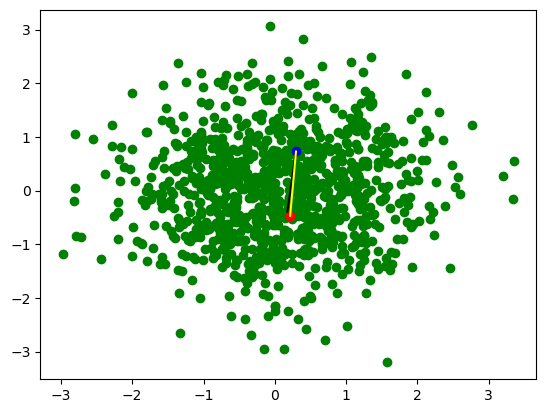

In [42]:
obs_arr = np.random.randn(1000,3)
exp_point = np.random.randn(3)
ref_point = np.random.rand(3)
sc, cos, dist, best_obs, best_idx = trajectory_score(obs_arr, exp_point, ref_point)
plt.scatter(obs_arr[:,0], obs_arr[:,1], color='green')
plt.scatter(exp_point[0], exp_point[1], color='red')
plt.scatter(ref_point[0], ref_point[1], color='blue')
plt.plot([ref_point[0], best_obs[0]], [ref_point[1], best_obs[1]], color='black')
plt.plot([ref_point[0], exp_point[0]], [ref_point[1], exp_point[1]], color='yellow')
print(sc, cos, dist, best_idx, best_obs, exp_point)

In [7]:
from MCMD_Sim.simulator.utils.tasks import get_task_delta
def infer_test_infer(infer_path, log_exist = True):
    result = []
    for infer_run in os.listdir(infer_path):
        init_cond_path = os.path.join(infer_path, infer_run, 'init_conditions.json')
        logs_path = os.path.join(infer_path, infer_run, 'logs.txt')
        if not os.path.exists(init_cond_path) or not os.path.exists(logs_path): continue
        init_cond = json.load(open(init_cond_path, 'r'))
        if log_exist:
            with open(logs_path, 'r') as f:
                label = f.read().strip().split('\n')
            label = label[-1].split('_')[1:]
            if len(label) < 4 or len(label) > 5:
                print(f'Not a valid log found in {infer_run}')
                continue
            elif len(label) == 4:
                env_name, task, command, tidx = label
            else:
                env_name, task1, task2, command, tidx = label
                task = task1 + '_' + task2
        else:
            env_name = init_cond['env_name']
            task = '2rb'
            command = init_cond['command']
            tidx = init_cond['target_idx']

        pos_arr = pd.read_csv(os.path.join(infer_path, infer_run, 'data', 'pos.csv')).to_numpy()
        target = np.array(init_cond["objects_loc"][init_cond["target_idx"]])
        exp_vec = get_task_delta(command)
        norm_exp = np.linalg.norm(exp_vec)
        exp_vec = exp_vec / norm_exp

        target[0] = min(target[0], pos_arr[-1, 0])
        obs_vec = pos_arr[:, :3] - target[None, :]
        norm_obs = np.linalg.norm(obs_vec, axis=1)
        norm_mask = norm_obs > 0
        obs_vec = obs_vec[norm_mask] / norm_obs[norm_mask][:, None]

        cos_sim = np.max(np.dot(obs_vec,exp_vec[:, None]))
        result.append({
            'infer_run': infer_run,
            'env_name': env_name,
            'task': task,
            'command': command,
            'tidx': tidx,
            'cos_sim': cos_sim
        })
    return pd.DataFrame(result)

pybullet build time: Nov 28 2023 23:52:03


In [16]:
result = infer_test_infer('/home/alex/flex/results_test/2025_04_18_18_35')

In [17]:
result

,infer_run,env_name,task,command,tidx,cos_sim
0,svit24p2h4d3_samurai40_below_0blue_2025_04_18_...,samurai,2rb,below,0,0.960671
1,svit24p2h4d3_arena25_towards_0blue_2025_04_18_...,arena,2rb,towards,0,0.979092
2,svit24p2h4d3_samurai04_above_0blue_2025_04_18_...,samurai,2rb,above,0,0.934720
3,svit24p2h4d3_samurai19_towards_0blue_2025_04_1...,samurai,2rb,towards,0,0.981272
4,svit24p2h4d3_arena50_right_1blue_2025_04_18_18...,arena,2rb,right,1,0.999905
5,svit24p2h4d3_samurai23_below_0blue_2025_04_18_...,samurai,2rb,below,0,0.896031
6,svit24p2h4d3_samurai50_right_0red_2025_04_18_1...,samurai,2rb,right,0,0.999818
7,svit24p2h4d3_samurai11_left_1red_2025_04_18_18...,samurai,2rb,left,1,0.999992
8,svit24p2h4d3_arena03_towards_0blue_2025_04_18_...,arena,2rb,towards,0,0.975920
9,svit24p2h4d3_samurai34_right_1red_2025_04_18_1...,samurai,2rb,right,1,0.999373


In [18]:
result_samurai = result[result['env_name'] == 'samurai']
result_arena = result[result['env_name'] == 'arena']

In [20]:
accuracy_by_command = (
    result.groupby("command")
    .apply(lambda x: [(x["cos_sim"] >= 0.85).sum(), (x["cos_sim"] >= -1).sum()])
)
print(accuracy_by_command)


command
above      [11, 12]
below      [12, 12]
left       [12, 12]
right      [12, 12]
towards    [12, 12]
dtype: object


/tmp/ipykernel_475132/376825350.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result.groupby("command")


In [5]:
from learning.src.models.components.policies.stop_policies import *

In [6]:
stop_transformer = StopFlaggerTransformer(128, 32)
stop_attn_transformer = StopFlaggerAttnTransformer(128, 32)
stop_dir_conv = StopFlaggerDirConv(128, 32)
stop_conv = StopFlaggeSimpleConv(128, 32)

In [7]:
count_param = lambda x: sum([p.numel() for p in x.parameters()])

In [10]:
count_param(stop_attn_transformer), count_param(stop_transformer), count_param(stop_dir_conv), count_param(stop_conv)

(17795, 17666, 4610, 4481)

In [ ]:
result_ = infer_test_eval

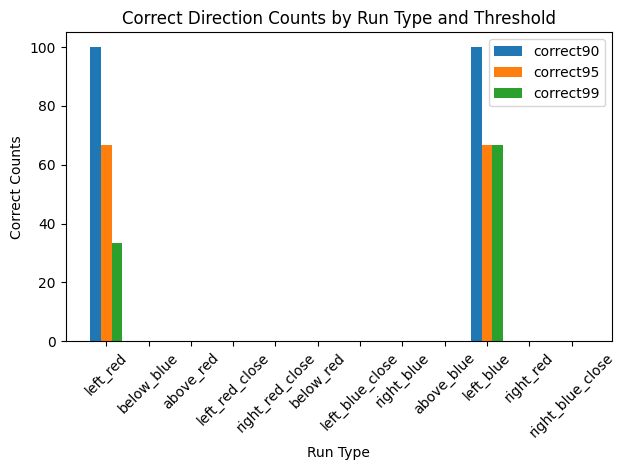

In [14]:
run_types = list(result_.keys())
categories = ['correct90', 'correct95', 'correct99']

x = np.arange(len(run_types))  # label locations
width = 0.25

fig, ax = plt.subplots()
for i, cat in enumerate(categories):
    ax.bar(x + i*width, [100 * result_[k][cat]/result_[k]['total'] for k in run_types], width, label=cat)

ax.set_xlabel('Run Type')
ax.set_ylabel('Correct Counts')
ax.set_title('Correct Direction Counts by Run Type and Threshold')
ax.set_xticks(x + width)
ax.set_xticklabels(run_types, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

In [3]:
import cv2

In [4]:
import matplotlib

In [2]:
import PIL
print(PIL.__version__)

from torchmetrics import Metric


11.1.0


In [1]:
import spacy

In [5]:
from vit_pytorch import SimpleViT
import torch

In [3]:
svit = SimpleViT(
    image_size=(32, 1),
    patch_size=(1, 1),
    num_classes=4,
    dim=128,
    depth=3,
    heads=4,
    mlp_dim=256,
    channels=64,
    dim_head=32
)

In [6]:
x = torch.randn(1, 64, 8, 8)

In [ ]:
svit(x)

torch.Size([1, 4])

In [11]:
svit.to_patch_embedding(x).shape

torch.Size([1, 8, 8, 128])

In [14]:
svit.__dict__

{'training': True,
 '_parameters': OrderedDict(),
 '_buffers': OrderedDict(),
 '_non_persistent_buffers_set': set(),
 '_backward_pre_hooks': OrderedDict(),
 '_backward_hooks': OrderedDict(),
 '_is_full_backward_hook': None,
 '_forward_hooks': OrderedDict(),
 '_forward_hooks_with_kwargs': OrderedDict(),
 '_forward_hooks_always_called': OrderedDict(),
 '_forward_pre_hooks': OrderedDict(),
 '_forward_pre_hooks_with_kwargs': OrderedDict(),
 '_state_dict_hooks': OrderedDict(),
 '_state_dict_pre_hooks': OrderedDict(),
 '_load_state_dict_pre_hooks': OrderedDict(),
 '_load_state_dict_post_hooks': OrderedDict(),
 '_modules': OrderedDict([('to_patch_embedding',
               Sequential(
                 (0): Rearrange('b c (h p1) (w p2) -> b h w (p1 p2 c)', p1=1, p2=1)
                 (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
                 (2): Linear(in_features=64, out_features=128, bias=True)
                 (3): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    

In [15]:
import inspect

In [18]:
inspect.getsource(svit.forward).split('\n')

['    def forward(self, img):',
 '        *_, h, w, dtype = *img.shape, img.dtype',
 '',
 '        x = self.to_patch_embedding(img)',
 '        pe = posemb_sincos_2d(x)',
 "        x = rearrange(x, 'b ... d -> b (...) d') + pe",
 '',
 '        x = self.transformer(x)',
 '        x = x.mean(dim = 1)',
 '',
 '        x = self.to_latent(x)',
 '        return self.linear_head(x)',
 '']

In [19]:
fpath = inspect.getsourcefile(svit.forward)

In [21]:
with open(fpath, 'r') as f:
    code = f.read()

print(code)

import torch
from torch import nn

from einops import rearrange
from einops.layers.torch import Rearrange

# helpers

def pair(t):
    return t if isinstance(t, tuple) else (t, t)

def posemb_sincos_2d(patches, temperature = 10000, dtype = torch.float32):
    _, h, w, dim, device, dtype = *patches.shape, patches.device, patches.dtype

    y, x = torch.meshgrid(torch.arange(h, device = device), torch.arange(w, device = device), indexing = 'ij')
    assert (dim % 4) == 0, 'feature dimension must be multiple of 4 for sincos emb'
    omega = torch.arange(dim // 4, device = device) / (dim // 4 - 1)
    omega = 1. / (temperature ** omega)

    y = y.flatten()[:, None] * omega[None, :]
    x = x.flatten()[:, None] * omega[None, :] 
    pe = torch.cat((x.sin(), x.cos(), y.sin(), y.cos()), dim = 1)
    return pe.type(dtype)

# classes

class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim)

In [1]:
class svit_cfg:
    image_size=(8, 8)
    patch_size=(1, 1)
    num_classes=4
    dim=128
    depth=3
    heads=4
    mlp_dim=256
    channels=64
    dim_head=32


In [2]:
from typing import Optional
from omegaconf import DictConfig # type: ignore
import torch
from torch import nn
import random

BasePolicy = nn.Module
from vit_pytorch import SimpleViT # type: ignore

dir_vocab = {'left': 0, 'right': 1, 'above': 2, 'below': 3, 'towards': 4}

class SViTPolicy(BasePolicy):
    def __init__(self, cfg: DictConfig):
        super().__init__()
        self.net = SimpleViT(
            image_size = cfg.image_size,
            patch_size = cfg.patch_size,
            num_classes = cfg.num_classes,
            dim = cfg.dim,
            depth = cfg.depth,
            heads = cfg.heads,
            mlp_dim = cfg.mlp_dim,
            channels = cfg.channels + len(dir_vocab),
            dim_head = cfg.dim_head,
        )

    def forward(self, x, dir_text: list[str]):
        device = x.device
        dir_idx = torch.tensor([dir_vocab[dir_] for dir_ in dir_text], device=device)
        dir_emb = torch.nn.functional.one_hot(dir_idx, num_classes=len(dir_vocab)).to(dtype=x.dtype)
        dir_emb = dir_emb.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, x.shape[2], x.shape[3])
        x = torch.cat((x, dir_emb), dim=1)

        return self.net(x)





In [3]:
svit = SViTPolicy(svit_cfg())

In [4]:
x = torch.randn(4, 64, 8, 8)

In [5]:
svit(x, random.choices(list(dir_vocab.keys()), k=x.shape[0]))

tensor([[ 0.2243, -0.1030, -0.5948, -0.4907],
        [ 0.5283, -0.1285, -0.8823, -0.5553],
        [ 0.0096,  0.2578, -0.5477, -0.7727],
        [ 0.2024,  0.2034, -0.5828, -0.8659]], grad_fn=<AddmmBackward0>)

In [44]:
random.choices(list(dir_vocab.keys()), k=7)

['right', 'above', 'right', 'above', 'towards', 'towards', 'right']

In [ ]:
def generate_closed_loop_1drone_2ball_env_init(
        env_name='arena', 
        command=None,
        target_idx=None,
        objs = None,
        log_path=None,
    ) -> SimEnvInit_1DroneSchema:
    """
    Specific implementation with weighted probabilities
    """
    if objs is None:
        objects_color = random.sample(ALL_COLORS, 2)
        object_type = ['ball', 'ball']
    else:
        objects_color = [obj.split(' ')[0] for obj in objs]
        object_type = [obj.split(' ')[1] for obj in objs] 
    
    command = command or random.choice(ALL_COMMANDS)
    if target_idx is None: target_idx = random.choice([0, 1])

    max_yaw_offset = 0.1 * np.pi
    ortho_dist = 0.2
    z_offset = 0.5 if env_name == 'arena' else 0.0

    theta_offset = random.uniform(0, max_yaw_offset)
    theta_environment = random.uniform(-np.pi, np.pi - max_yaw_offset)

    pybullet_rand_forward1 = random.uniform(1.5, 2.5)
    pybullet_rand_forward2 = random.uniform(1.5, 2.5)
    drone_zrand = random.uniform(0.5, 0.8) + z_offset
    # Convert to GS
    gs_rand_x1 = pybullet_rand_forward1 * PYBULLET_TO_GS_SCALING_FACTOR
    gs_rand_x2 = pybullet_rand_forward2 * PYBULLET_TO_GS_SCALING_FACTOR

    gs_offsets_from_camera = np.array([
        [0, 0, 0], 
        [gs_rand_x1, random.uniform(-2.5, -1.5) * ortho_dist, random.uniform(-0.4, 0.4) + drone_zrand],
        [gs_rand_x2, random.uniform(1.5, 2.5) * ortho_dist, random.uniform(-0.4, 0.4) + drone_zrand]
    ], dtype=np.float32)  # forward, right, up
    
    # NOTE: y is opposite in pybullet compared to GS coordinates, so we flip it here:
    objects_xyz = (gs_offsets_from_camera[1:, :] / PYBULLET_TO_GS_SCALING_FACTOR) * np.array([1, -1, 1])
    drones_loc = [[0.0, 0.0, drone_zrand]]

    _schema = SimEnvInit_1DroneSchema()
    init_conditions = {
        "drones_loc": drones_loc,
        "theta_offset": theta_offset,
        "theta_environment": theta_environment,
        "objects_loc": objects_xyz.tolist(),
        "objects_color": objects_color,
        "objects_type": object_type,
        'target_idx': target_idx,
        'command': command,
        "env_name": env_name,
        "PYBULLET_TO_GS_SCALING_FACTOR": PYBULLET_TO_GS_SCALING_FACTOR,
        "gs_objects_relative": np.array(gs_offsets_from_camera)[1:, 0:2].tolist()
    }
    if log_path is not None: init_conditions['log_dir'] = log_path
    init_conditions = _schema.load(init_conditions)

    return init_conditions

In [2]:
import plotly.graph_objects as go
import numpy as np
import os
import json
import pandas as pd

In [13]:
class SimConfig:
    theta_env = 0
    log_path = '/home/alex/flex/results_test'

In [4]:
# Define mappings from matplotlib to Plotly
mpl_to_plotly_colors = {
    'r': 'red', 'b': 'blue', 'y': 'yellow', 'g': 'green', 'm': 'purple', 'k': 'black'
}

mpl_to_plotly_symbols = {
    'o': 'circle',
    's': 'square',
    '^': 'diamond-open',
    'P': 'cross',
    '*': 'square-open',
    'X': 'x',
    'v': 'diamond-open',
    'D': 'diamond',
    '>': 'circle-open',
    '.': 'circle-open'
}

In [5]:


def plot_trajectory_3d(pos_data, yaw_data, plotname='3d', objs=None, save_html=False):
    fig = go.Figure()

    # 3D trajectory line
    fig.add_trace(go.Scatter3d(
        x=pos_data[:, 0], y=pos_data[:, 1], z=pos_data[:, 2],
        mode='lines+markers',
        line=dict(color='blue'),
        marker=dict(size=3),
        name='Trajectory'
    ))

    # Add yaw arrows (as cones in 3D but flat on xy-plane)
    step = 5
    for i in range(0, len(yaw_data), step):
        x, y, z = pos_data[i]
        ang = yaw_data[i] - SimConfig.theta_env + 2 * np.pi
        dx, dy = 0.2 * np.cos(ang), 0.2 * np.sin(ang)
        fig.add_trace(go.Cone(
            x=[x], y=[y], z=[z],
            u=[dx], v=[dy], w=[0],  # w=0 → flat on XY
            sizemode="absolute",
            sizeref=0.1,
            anchor="tail",
            colorscale="Reds",
            showscale=False,
            name="Yaw Arrows"
        ))

    # Plot optional objects
    if objs is not None:
        for obj in objs:
            ox, oy, oz = obj['x'], obj['y'], obj.get('z', 0)
            # Extract style
            style = obj.get('style', 'ro')  # fallback to red circle
            color_code = style[0]
            symbol_code = style[1] if len(style) > 1 else 'o'

            color = mpl_to_plotly_colors.get(color_code, 'black')
            symbol = mpl_to_plotly_symbols.get(symbol_code, 'circle')
            fig.add_trace(go.Scatter3d(
                x=[ox], y=[oy], z=[oz],
                mode='markers',
                marker=dict(size=5, color=color, symbol=symbol),
                name=obj.get('label', 'Object')
            ))
            # Add a transparent sphere/circle (not a perfect circle, but an approximation)
            u = np.linspace(0, 2 * np.pi, 30)
            cx = ox + 0.5 * np.cos(u)
            cy = oy + 0.5 * np.sin(u)
            cz = np.ones_like(u) * oz
            fig.add_trace(go.Scatter3d(
                x=cx, y=cy, z=cz,
                mode='lines',
                line=dict(color='red', dash='dot'),
                showlegend=False
            ))

    fig.update_layout(
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
            aspectmode='data',
        ),
        title='3D Trajectory with Yaw and Objects',
        margin=dict(l=0, r=0, b=0, t=40),
        showlegend=True
    )

    if save_html:
        filename = os.path.join(SimConfig.log_path, f"{plotname}_3d_{SimConfig.log_path[-13:].replace('/', '_')}.html")
        fig.write_html(filename)
        print(f"Saved interactive 3D plot to {filename}")

    fig.show()


In [6]:
run_path = '/home/alex/flex/results_test/2025_04_12_15_09/svit24p2h4d3_arena21_right_0red_2025_04_12_15_10_21'

In [7]:
init_cond = json.load(open(os.path.join(run_path, 'init_conditions.json'), 'r'))
SimConfig.theta_env = init_cond['theta_environment']
pos_arr = pd.read_csv(os.path.join(run_path, 'data', 'pos.csv')).to_numpy()

In [8]:
from MCMD_Sim.simulator.utils.logger import SimLogger
from MCMD_Sim.simulator.components.simobjects import SimObject

pybullet build time: Nov 28 2023 23:52:03


In [9]:
objs = [SimObject(lrel, init_cond['theta_environment'], colr, otype)
        for lrel, colr, otype in zip(init_cond['objects_loc'], init_cond['objects_color'], init_cond['objects_type'])]

In [10]:
objs = [SimLogger.parse_obj(obj) for obj in objs]

In [11]:
objs

[{'x': 1.78433459355079, 'y': 0.30000000000000004, 'z': 1.1, 'style': 'ro'},
 {'x': 1.78433459355079, 'y': -0.30000000000000004, 'z': 1.1, 'style': 'bo'}]

In [14]:
plot_trajectory_3d(pos_arr[:, :3], pos_arr[:, 3], plotname='3d', objs=objs, save_html=True)

Saved interactive 3D plot to /home/alex/flex/results_test/3d_3d__results_test.html
